<a href="https://colab.research.google.com/github/jakster448/lis5693/blob/main/lab-4/Lab_Assignment_4_Supervised_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1
The `review` column was selected as the feature because it contains the actual text of each movie review, which provides the information needed to determine sentiment. The `sentiment` column was chosen as the target label because it indicates whether the review is positive or negative. During the classification process, the model analyzes patterns in the review text and learns how certain words and phrases relate to positive or negative sentiment. This allows the trained model to predict the sentiment of new reviews that it has not seen before.

In [1]:
!wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

--2026-03-12 23:41:04--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  10.6MB/s    in 19s     

2026-03-12 23:41:24 (4.14 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]



In [2]:
import tarfile

with tarfile.open("aclImdb_v1.tar.gz", "r:gz") as tar:
    tar.extractall()

/tmp/ipykernel_487/537903209.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [3]:
import os
import pandas as pd

reviews = []
sentiments = []

base_dir = "aclImdb/train"

for label in ["pos", "neg"]:
    folder = os.path.join(base_dir, label)

    for file in os.listdir(folder):
        with open(os.path.join(folder, file), encoding="utf-8") as f:
            reviews.append(f.read())
            sentiments.append(label)

df = pd.DataFrame({
    "review": reviews,
    "sentiment": sentiments
})

df.to_csv("imdb_reviews.csv", index=False)

print(df.shape)

(25000, 2)


In [4]:
import os
os.listdir("aclImdb")

['train', 'test', 'README', 'imdbEr.txt', 'imdb.vocab']

In [5]:
import os
import pandas as pd

reviews = []
sentiments = []

base_dir = "aclImdb/train"

for label in ["pos", "neg"]:
    folder = os.path.join(base_dir, label)

    for file in os.listdir(folder):
        with open(os.path.join(folder, file), encoding="utf-8") as f:
            reviews.append(f.read())
            sentiments.append(label)

df = pd.DataFrame({
    "review": reviews,
    "sentiment": sentiments
})

print(df.shape)

df.to_csv("imdb_reviews.csv", index=False)

(25000, 2)


In [6]:
from google.colab import files
files.download("imdb_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/jakster448/lis5693/refs/heads/main/lab-4/imdb_reviews.csv"
df = pd.read_csv(url)

df.head()

,review,sentiment
0,Lars Von Triers Europa is an extremely good fi...,pos
1,I did watch all of the film through to the dis...,neg
2,"I knew about but had never seen Grey Gardens, ...",pos
3,Deep Shock plays out like a TV movie: a whole ...,neg
4,Horrible film. About an old crusty painter who...,neg


TASK 2

In [8]:
from sklearn.model_selection import train_test_split

X = df["review"]      # features
y = df["sentiment"]   # labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 3500
Testing size: 1500


TASK 3:
Three classifiers were trained using the training dataset: Logistic Regression, Naive Bayes (MultinomialNB), and Support Vector Machine (LinearSVC). Each model was evaluated using accuracy, precision, recall, and F1-score to measure their performance on the test dataset.

Logistic Regression performed well and produced balanced results across all evaluation metrics. Naive Bayes trained very quickly and performed reasonably well, but its accuracy and F1-score were slightly lower compared to the other models. The Support Vector Machine (SVM) achieved the highest accuracy and F1-score among the three classifiers. This is likely because SVM is effective at separating high-dimensional data such as TF-IDF text vectors, allowing it to better distinguish between positive and negative reviews.

Based on these results, the SVM model was selected as the best-performing classifier. A confusion matrix was generated to further analyze its predictions. The confusion matrix displays how many reviews were correctly and incorrectly classified by the model.

In the confusion matrix:
- True Positives represent positive reviews that were correctly predicted as positive.
- True Negatives represent negative reviews that were correctly predicted as negative.
- False Positives represent negative reviews that were incorrectly predicted as positive.
- False Negatives represent positive reviews that were incorrectly predicted as negative.

The values in the confusion matrix show that most reviews were classified correctly, with only a small number of misclassifications. This indicates that the model was generally successful at identifying sentiment in the movie reviews, although some errors occurred due to ambiguous wording or mixed sentiment in certain reviews.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [11]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

MultinomialNB()

In [12]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_vec, y_train)

LinearSVC()

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "SVM": svm
}

for name, model in models.items():

    preds = model.predict(X_test_vec)

    print(name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds, pos_label="pos"))
    print("Recall:", recall_score(y_test, preds, pos_label="pos"))
    print("F1 Score:", f1_score(y_test, preds, pos_label="pos"))
    print()

Logistic Regression
Accuracy: 0.8473333333333334
Precision: 0.8224414303329223
Recall: 0.886968085106383
F1 Score: 0.853486884197057

Naive Bayes
Accuracy: 0.8353333333333334
Precision: 0.8292046936114733
Recall: 0.8457446808510638
F1 Score: 0.837393021724819

SVM
Accuracy: 0.8453333333333334
Precision: 0.8299492385786802
Recall: 0.8696808510638298
F1 Score: 0.8493506493506493



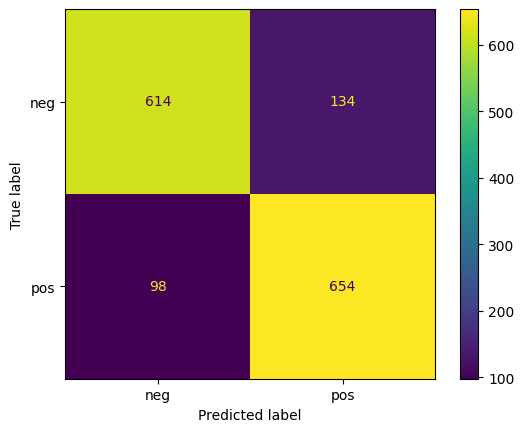

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = svm.predict(X_test_vec)

ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.show()

TASK 4:
8 were classified correctly and 2 were incorrectly classified.

In [15]:
pseudo_reviews = X_test.sample(100, random_state=42)

pseudo_df = pseudo_reviews.to_frame()

pseudo_df["sentiment"] = ""

pseudo_df.to_csv("pseudo_reviews.csv", index=False)

pseudo_df.head()

,review,sentiment
790,"Last week, I took a look at the weekly Nielsen...",
2879,I am sad that a period of history that is so f...,
2372,I don't understand why the other comments focu...,
1351,I have two very major complaints regarding thi...,
3382,What happened in the making of this movie so t...,


In [20]:
pseudo_df = pd.read_csv("pseudo_reviews.csv")

pseudo_df.head()

,review,sentiment
0,"Last week, I took a look at the weekly Nielsen...",NaN
1,I am sad that a period of history that is so f...,NaN
2,I don't understand why the other comments focu...,NaN
3,I have two very major complaints regarding thi...,NaN
4,What happened in the making of this movie so t...,NaN


In [26]:
pseudo_vec = vectorizer.transform(pseudo_df["review"])

predictions = svm.predict(pseudo_vec)

pseudo_df["sentiment"] = predictions

pseudo_df.to_csv("predicted.csv", index=False)

pseudo_df.head()

,review,sentiment
0,"Last week, I took a look at the weekly Nielsen...",pos
1,I am sad that a period of history that is so f...,neg
2,I don't understand why the other comments focu...,neg
3,I have two very major complaints regarding thi...,neg
4,What happened in the making of this movie so t...,pos


TASK 5:
Overall, this assignment helped demonstrate the process of building a machine learning text classification model from start to finish. One thing that went well was successfully preprocessing the text data and training multiple classifiers to compare their performance. Evaluating the models using different metrics made it easier to determine which algorithm performed best. One challenge encountered was handling the dataset size and converting the raw review files into a format that could be uploaded to GitHub and used in the notebook. Despite these challenges, the assignment provided valuable experience with supervised learning, text preprocessing, and evaluating classification models.